# **Energy Efficiency**

Este estudo analisou a avaliação dos requisitos de carga de aquecimento e carga de resfriamento de edifícios (ou seja, eficiência energética) como uma função dos parâmetros de construção.


**Feature**
  * X1			**Relative Compactness**	 Continuous
  * X2	  	**Surface Area**		 Continuous
  * X3			**Wall Area**		Continuous
  * X4	  	**Roof Area**		Continuous
  * X6			**Orientation**		Integer
  * X7		**Glazing Area**		Continuous
  * X8	 **Glazing Are**  Distribution

**Target**
  * Y1		**Heating Load**	 Continuous
  * Y2		**Cooling Load**		Continuous

In [9]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
data = pd.read_excel(url)
df =data.copy()

# **Explorando os dados**

In [10]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


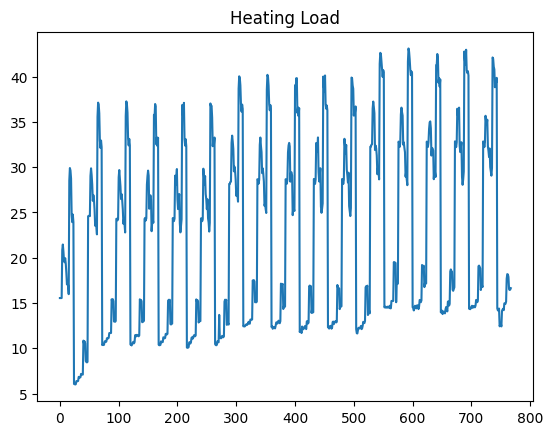

In [11]:
# Dados de exemplo
import seaborn as sns
import matplotlib.pyplot as plt
# Cria o boxplot
plt.plot(df["Y1"].values, label="Heating Load")


# Adiciona um título
plt.title('Heating Load')

# Mostra o gráfico
plt.show()

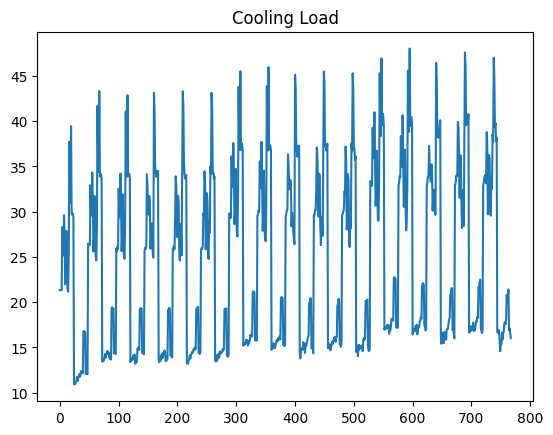

In [12]:
# Dados de exemplo
import seaborn as sns
import matplotlib.pyplot as plt
# Cria o boxplot
plt.plot(df["Y2"].values,label ="Cooling Load" )


# Adiciona um título
plt.title('Cooling Load')

# Mostra o gráfico
plt.show()




In [13]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


# **Alocando base de treino e base de teste**
* X_treinamento, y_treinamento
* X_teste, y_teste

In [14]:
X = data.iloc[:, :-2] # Selecionando os atributos previsores "X1	X2	X3	X4	X5	X6	X7	X8"
y = data.iloc[:, -2:] # Slecionando os alvos  Y1 , Y2

In [15]:
#Verificando dimensões
X.shape, y.shape

((768, 8), (768, 2))

# **Padronizando os dados**

In [16]:
from sklearn.preprocessing import StandardScaler
# As redes neurais são muito sensiveis a escala dos numeros, portanto, devemos padrozinar.


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X) # padronizando X -> X_scaled
y_scaled = scaler_y.fit_transform(y) # padronizando Y ->  Y_scaled

# **Particionando as bases**

In [17]:
# Precisamos dividor os dados em treinamento e teste,para isto fazemos uso do train_test_split

import sklearn
from sklearn.model_selection import train_test_split

In [18]:
#Serão utilizados 75% dos dados para teinamento e 25% dos dados para teste
# train_test_split(X_scaled ,y_scaled, test_size=0.25)

#X_scaled  -> X_treinamento_scaled, X_teste_scaled
#,y_scaled -> y_treinamento_scaled,y_teste_scaled


X_treinamento_scaled,X_teste_scaled, y_treinamento_scaled,y_teste_scaled = train_test_split(X_scaled ,y_scaled, test_size=0.25)

In [19]:
#verificando as dimensões das bases de treinamento
X_treinamento_scaled.shape, y_treinamento_scaled.shape

# y_treinamento_scaled possui duas colunas,  Y1 Heating Load  e  Y2 Cooling Load

((576, 8), (576, 2))

In [20]:
from sklearn.neural_network import MLPRegressor

In [21]:
# Criar o modelo MLP
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 80),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

In [22]:
# Treinar o modelo
#Treinamento do modelo mlp_regressor  com  X_treinamento_scaled, y_treinamento_scaled
history = mlp_regressor.fit(X_treinamento_scaled, y_treinamento_scaled)



Iteration 1, loss = 0.45533361
Validation score: 0.262899
Iteration 2, loss = 0.33577694
Validation score: 0.485973
Iteration 3, loss = 0.23895003
Validation score: 0.663803
Iteration 4, loss = 0.16478782
Validation score: 0.790699
Iteration 5, loss = 0.11323603
Validation score: 0.867028
Iteration 6, loss = 0.08285765
Validation score: 0.896026
Iteration 7, loss = 0.07140800
Validation score: 0.892354
Iteration 8, loss = 0.06992803
Validation score: 0.882049
Iteration 9, loss = 0.06905983
Validation score: 0.885799
Iteration 10, loss = 0.06408305
Validation score: 0.902079
Iteration 11, loss = 0.05683969
Validation score: 0.916142
Iteration 12, loss = 0.05231657
Validation score: 0.921355
Iteration 13, loss = 0.05056723
Validation score: 0.920020
Iteration 14, loss = 0.05011665
Validation score: 0.919280
Iteration 15, loss = 0.04972557
Validation score: 0.922017
Iteration 16, loss = 0.04860227
Validation score: 0.927950
Iteration 17, loss = 0.04687541
Validation score: 0.934076
Iterat

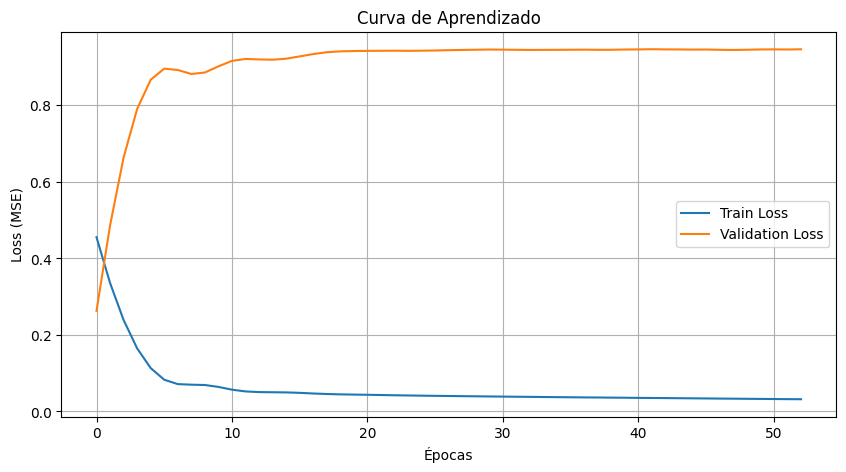

In [23]:
# Plotar a perda durante o treinamento
plt.figure(figsize=(10, 5))
plt.plot(history.loss_curve_, label='Train Loss')
plt.plot(history.validation_scores_, label='Validation Loss')
plt.title('Curva de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid()
plt.show()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score


# Previsões
y_previsto_scaled = mlp_regressor.predict(X_teste_scaled) # y_previsto_scaled [:,  2]
y_previsto = scaler_y.inverse_transform(y_previsto_scaled)
y_teste =scaler_y.inverse_transform(y_teste_scaled)

In [29]:
# Métricas para Heating Load (Target 1)
print("\nPerformance para Heating Load:")
print(f"MSE: {mean_squared_error(y_teste[:, 0], y_previsto[:, 0]):.3f}")
print(f"R²: {r2_score(y_teste[:, 0], y_previsto[:, 0]):.3f}")

# Métricas para Cooling Load (Target 2)
print("\nPerformance para Cooling Load:")
print(f"MSE: {mean_squared_error(y_teste[:, 1], y_previsto[:, 1]):.3f}")
print(f"R²: {r2_score(y_teste[:, 1], y_previsto[:, 1]):.3f}")



Performance para Heating Load:
MSE: 6.460
R²: 0.933

Performance para Cooling Load:
MSE: 9.042
R²: 0.895


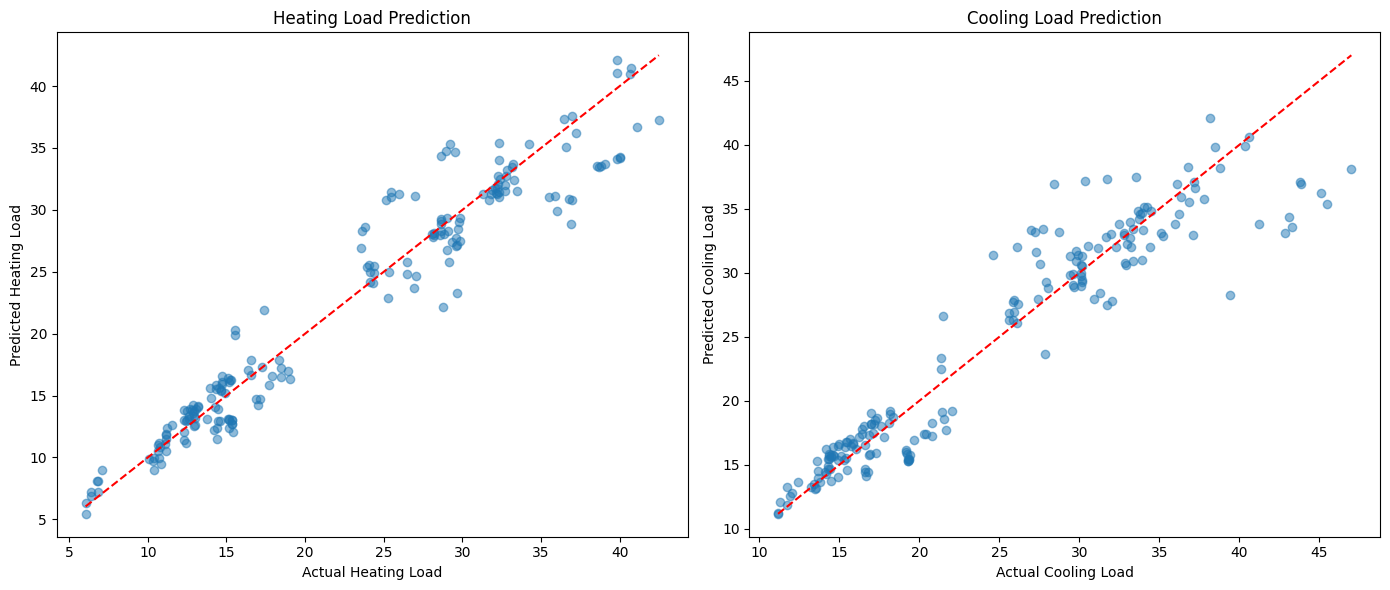

In [30]:

# Gráfico de dispersão para os targets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Heating Load
ax1.scatter(y_teste[:, 0], y_previsto[:, 0], alpha=0.5)
ax1.plot([y_teste[:, 0].min(), y_teste[:, 0].max()],
         [y_teste[:, 0].min(), y_teste[:, 0].max()], 'r--')
ax1.set_xlabel('Actual Heating Load')
ax1.set_ylabel('Predicted Heating Load')
ax1.set_title('Heating Load Prediction')

# Cooling Load
ax2.scatter(y_teste[:, 1], y_previsto[:, 1], alpha=0.5)
ax2.plot([y_teste[:, 1].min(), y_teste[:, 1].max()],
         [y_teste[:, 1].min(), y_teste[:, 1].max()], 'r--')
ax2.set_xlabel('Actual Cooling Load')
ax2.set_ylabel('Predicted Cooling Load')
ax2.set_title('Cooling Load Prediction')

plt.tight_layout()
plt.show()

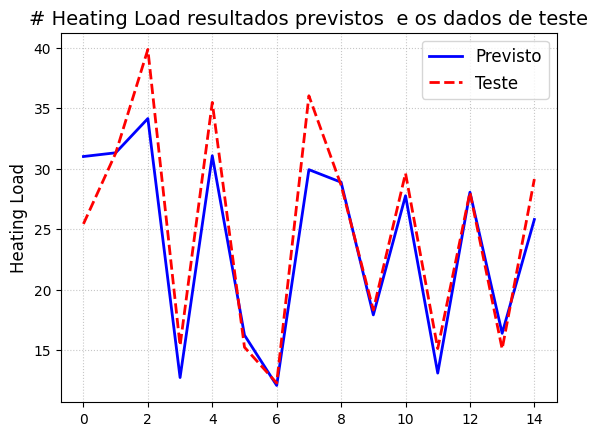

In [31]:
# Plotando as duas curvas

# Heating Load

plt.plot( y_previsto[0:15:,0], 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste[0:15:,0], 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('# Heating Load resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Heating Load', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='upper right')  # Legenda



# Mostrando o gráfico
plt.show()

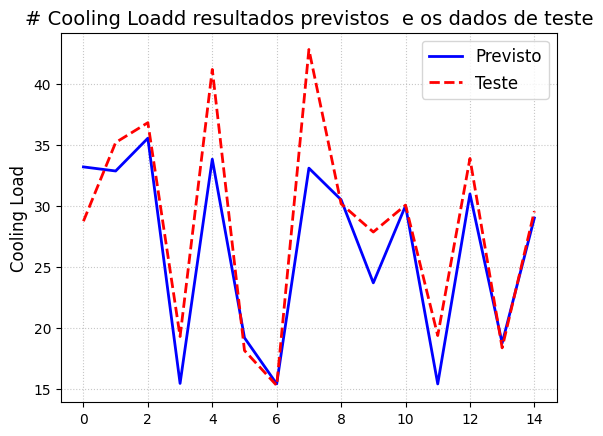

In [32]:
# Plotando as duas curvas

# Cooling Load

plt.plot( y_previsto[0:15:,1], 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste[0:15:,1], 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('# Cooling Loadd resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Cooling Load', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='upper right')  # Legenda



# Mostrando o gráfico
plt.show()